In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split

 BASES DE DATOS

In [2]:
df1= pd.read_csv("ANEXO 1 DF MODELO1.CSV")
df2= pd.read_csv("ANEXO 2 DF MODELO2.CSV")
df3= pd.read_csv("ANEXO 3 DF MODELO3.CSV")

VARIABLES 

In [3]:
x1="dm2"
x2="ganchera"

y="und" # hace refencia al tiempo de aplicación de recubrimientos orgánicos

REGRESIÓN LINEAL MULTIPLE (COEFICIENTES)

In [16]:
modelo1= LinearRegression()
modelo1.fit(df1[[x1,x2]],df1[y])
r1=round(r2_score(df1[y],modelo1.predict(df1[[x1,x2]])),3)

modelo2= LinearRegression()
modelo2.fit(df2[[x1,x2]],df2[y])
r2=round(r2_score(df2[y],modelo2.predict(df2[[x1,x2]])),3)

modelo3= LinearRegression()
modelo3.fit(df3[[x1,x2]],df3[y])
r3=round(r2_score(df3[y],modelo3.predict(df3[[x1,x2]])),3)

tabla_regresionm = pd.DataFrame({
    'Modelo': ['1', '2', '3'],
    'Coeficiente R2': [r1, r2,r3],
})

print(tabla_regresionm)


  Modelo  Coeficiente R2
0      1           0.954
1      2           0.982
2      3           0.908


ECUACIÓN MODELO 1

In [17]:
print(f"b0 = {modelo1.intercept_}")
print(f"b1 = {modelo1.coef_[0]}")
print(f"b1 = {modelo1.coef_[1]}")

b0 = 35.1861882418995
b1 = 30.22030592259202
b1 = -2.5083804555187412


ECUACIÓN MODELO 2

In [19]:
print(f"b0 = {modelo2.intercept_}")
print(f"b1 = {modelo2.coef_[0]}")
print(f"b1 = {modelo2.coef_[1]}")

b0 = 52.94847941527446
b1 = 33.02638195088264
b1 = -3.3629694743782657


ECUACIÓN MODELO 3

In [20]:
print(f"b0 = {modelo3.intercept_}")
print(f"b1 = {modelo3.coef_[0]}")
print(f"b1 = {modelo3.coef_[1]}")

b0 = 28.768895619455485
b1 = 13.3546252888908
b1 = -1.6139175920936901


ÁRBOLES DE DECISIÓN (COEFICIENTES)

In [ ]:
modelo1= DecisionTreeRegressor(min_samples_split=10)
modelo1.fit(df1[[x1,x2]],df1[y])
r1=round(r2_score(df1[y],modelo1.predict(df1[[x1,x2]])),3)

modelo2= DecisionTreeRegressor(min_samples_split=10)
modelo2.fit(df2[[x1,x2]],df2[y])
r2=round(r2_score(df2[y],modelo2.predict(df2[[x1,x2]])),3)

modelo3= DecisionTreeRegressor(min_samples_split=10)
modelo3.fit(df3[[x1,x2]],df3[y])
r3=round(r2_score(df3[y],modelo3.predict(df3[[x1,x2]])),3)

tabla_Decisiontree = pd.DataFrame({
    'Modelo': ['1', '2', '3'],
    'Coeficiente R2': [r1, r2,r3],
})

print(tabla_Decisiontree)


y_pred = modelo.predict([[4.73115,2]])
print("predicion:", y_pred)


  Modelo  Coeficiente R2
0      1           0.963
1      2           0.992
2      3           0.960


ÁRBOL MODELO 1

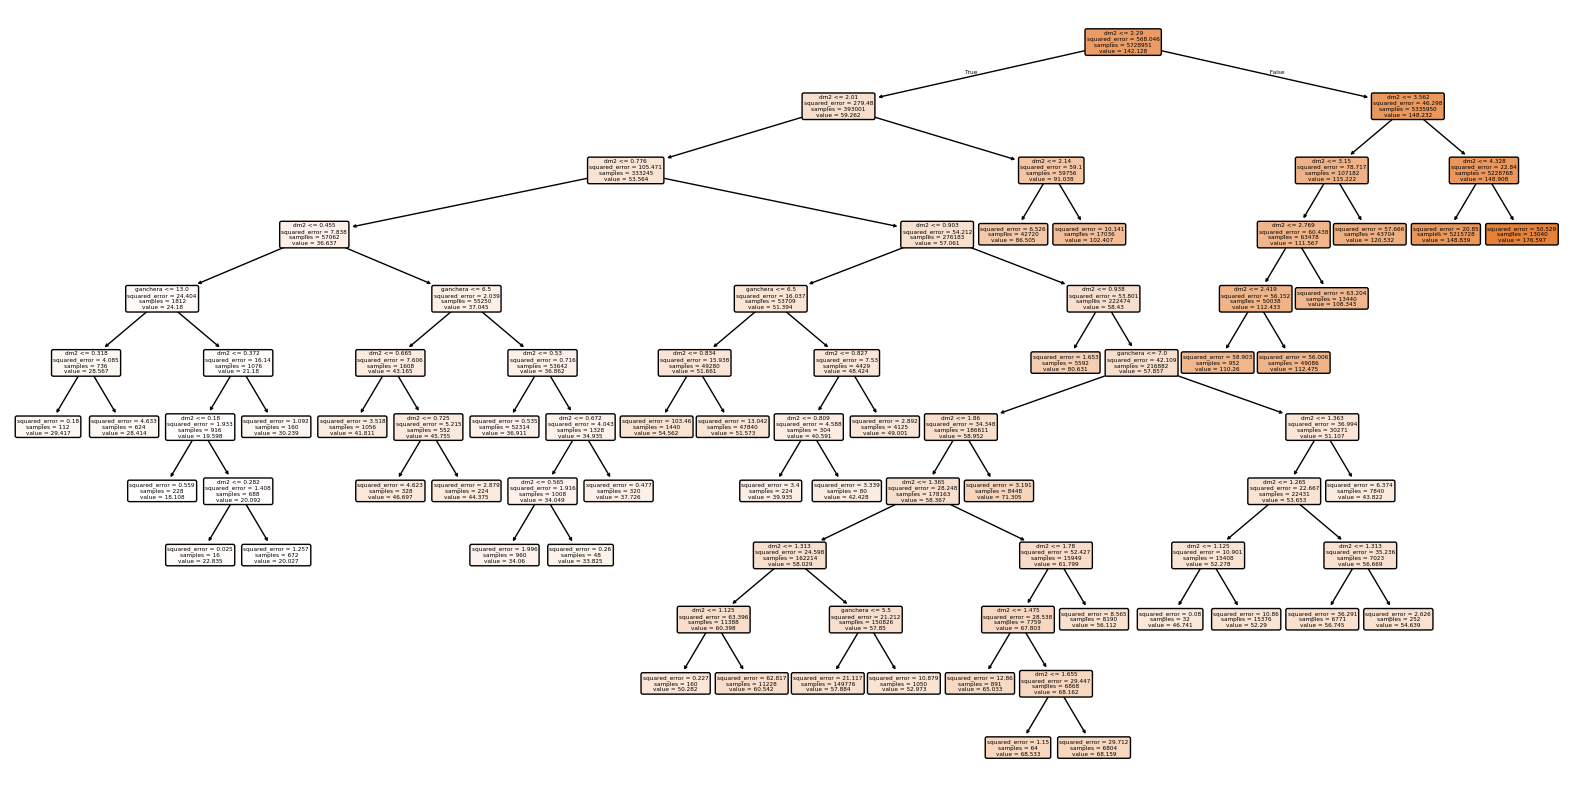

In [29]:
x=df1[[x1,x2]]
plt.figure(figsize=(20,10))
plot_tree(
    modelo1,
    feature_names=x.columns,
    filled=True,
    rounded=True
)
plt.show()

ÁRBOL MODELO 2

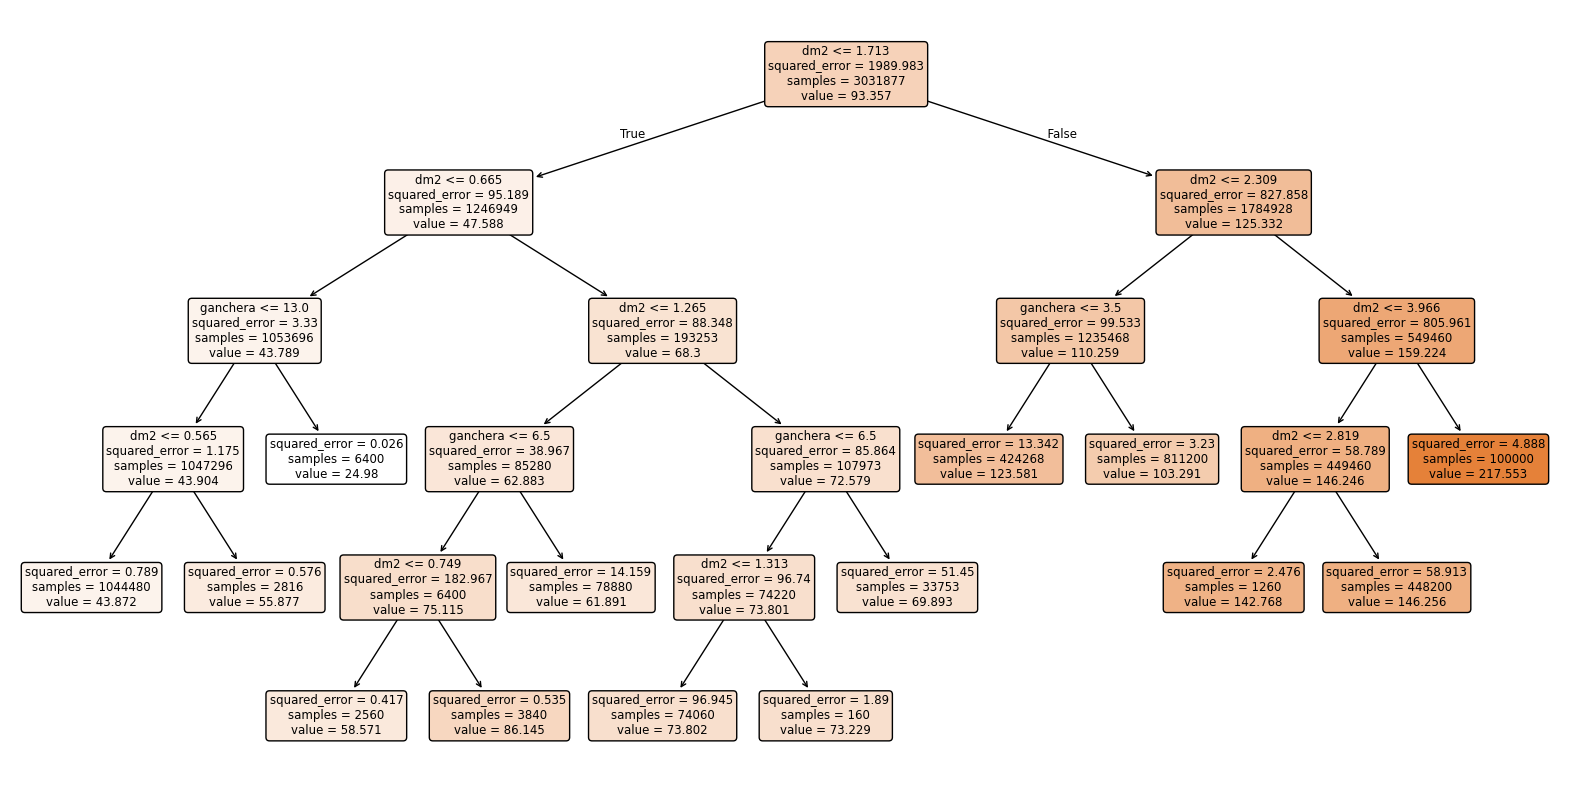

In [30]:
x=df2[[x1,x2]]
plt.figure(figsize=(20,10))
plot_tree(
    modelo2,
    feature_names=x.columns,
    filled=True,
    rounded=True
)
plt.show()

ÁRBOL MODELO 2

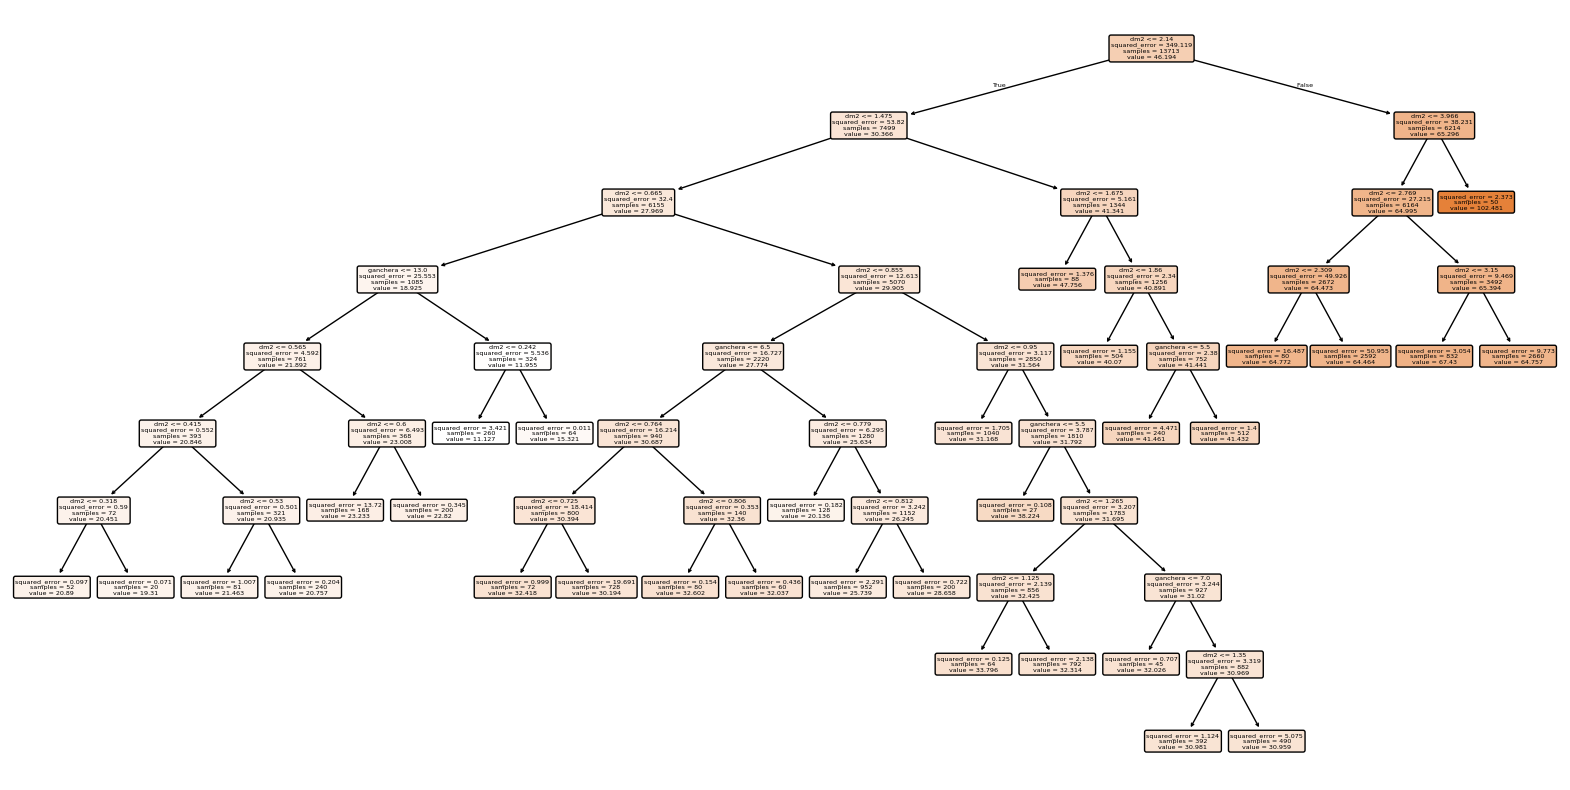

In [31]:
x=df3[[x1,x2]]
plt.figure(figsize=(20,10))
plot_tree(
    modelo3,
    feature_names=x.columns,
    filled=True,
    rounded=True
)
plt.show()

MAE Y RMSE MODELO 1

In [ ]:
#PARA REALIZAR ESTA SECCIÓN FUE NECESARIO USAR UNA METODOLOGÍA DE ENTRENAMIENTO YA QUE POR CONFIDENCIALIDAD NO SE PUEDE CARGAR LA BASE DE DATOS CON TIEMPOS ESTANDAR REALES
X_train, X_test, y_train, y_test = train_test_split(
    df1[[x1,x2]],
    df1[y],
    test_size=0.25,
    random_state=42
)

modelo= DecisionTreeRegressor(min_samples_split=10)
modelo.fit(X_train,y_train)

y_pred = modelo.predict(X_test)

df_eval = X_test.copy()
df_eval['tiempo_real'] = y_test.values
df_eval['tiempo_predicho'] = y_pred
df_eval['error'] = df_eval['tiempo_real'] - df_eval['tiempo_predicho']

df_eval['error_abs'] = df_eval['error'].abs()
df_eval['error_rel'] = df_eval['error_abs'] / df_eval['tiempo_real']

resumen = {
    'MAE (min)': df_eval['error_abs'].mean(),
    'RMSE (min)': np.sqrt((df_eval['error']**2).mean()),
}

df_resumen = pd.DataFrame.from_dict(resumen, orient='index', columns=['Valor'])
print(pd.DataFrame(df_resumen))

              Valor
MAE (min)   3.65574
RMSE (min)  4.61082


MAE Y RMSE MODELO 2

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    df2[[x1,x2]],
    df2[y],
    test_size=0.25,
    random_state=42
)

modelo= DecisionTreeRegressor(min_samples_split=10)
modelo.fit(X_train,y_train)

y_pred = modelo.predict(X_test)

df_eval = X_test.copy()
df_eval['tiempo_real'] = y_test.values
df_eval['tiempo_predicho'] = y_pred
df_eval['error'] = df_eval['tiempo_real'] - df_eval['tiempo_predicho']

df_eval['error_abs'] = df_eval['error'].abs()
df_eval['error_rel'] = df_eval['error_abs'] / df_eval['tiempo_real']

resumen = {
    'MAE (min)': df_eval['error_abs'].mean(),
    'RMSE (min)': np.sqrt((df_eval['error']**2).mean()),
}

df_resumen = pd.DataFrame.from_dict(resumen, orient='index', columns=['Valor'])
print(pd.DataFrame(df_resumen))

               Valor
MAE (min)   2.355121
RMSE (min)  3.898798


MAE Y RMSE MODELO 3

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    df2[[x1,x2]],
    df2[y],
    test_size=0.25,
    random_state=42
)

modelo= DecisionTreeRegressor(min_samples_split=10)
modelo.fit(X_train,y_train)

y_pred = modelo.predict(X_test)

df_eval = X_test.copy()
df_eval['tiempo_real'] = y_test.values
df_eval['tiempo_predicho'] = y_pred
df_eval['error'] = df_eval['tiempo_real'] - df_eval['tiempo_predicho']

df_eval['error_abs'] = df_eval['error'].abs()
df_eval['error_rel'] = df_eval['error_abs'] / df_eval['tiempo_real']

resumen = {
    'MAE (min)': df_eval['error_abs'].mean(),
    'RMSE (min)': np.sqrt((df_eval['error']**2).mean()),
}

df_resumen = pd.DataFrame.from_dict(resumen, orient='index', columns=['Valor'])
print(pd.DataFrame(df_resumen))

               Valor
MAE (min)   2.355121
RMSE (min)  3.898798


In [ ]:
profundidades = range(1, 21)

error_train = []
error_test = []

for d in profundidades:

    modelo = DecisionTreeRegressor(
        max_depth=d,
        min_samples_split=10,
        
    )

    modelo.fit(X_train, y_train)

    # predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # errores
    error_train.append(mean_squared_error(y_train, y_pred_train))
    error_test.append(mean_squared_error(y_test, y_pred_test))

In [ ]:
modelo1= DecisionTreeRegressor(min_samples_split=10)
modelo1.fit(df1[[x1,x2]],df1[y])
r1=round(r2_score(df1[y],modelo1.predict(df1[[x1,x2]])),3)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x1, x2, test_size=0.2, random_state=42
)

# =========================
# 2. Evaluar distintas profundidades
# =========================
depths = range(1, 21)

train_error = []
test_error = []

for d in depths:
    
    model = DecisionTreeRegressor(
        max_depth=d,
        min_samples_split=10
    )
    
    model.fit(X_train, y_train)

    # predicciones
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # MSE
    train_error.append(mean_squared_error(y_train, y_train_pred))
    test_error.append(mean_squared_error(y_test, y_test_pred))

# =========================
# 3. Gráfica
# =========================
plt.figure(figsize=(8,5))

plt.plot(depths, train_error, label="Error entrenamiento")
plt.plot(depths, test_error, label="Error prueba")

plt.xlabel("Profundidad del árbol")
plt.ylabel("MSE")
plt.title("Diagnóstico de sobreajuste en árbol de decisión")

plt.legend()
plt.grid(True)

plt.show()

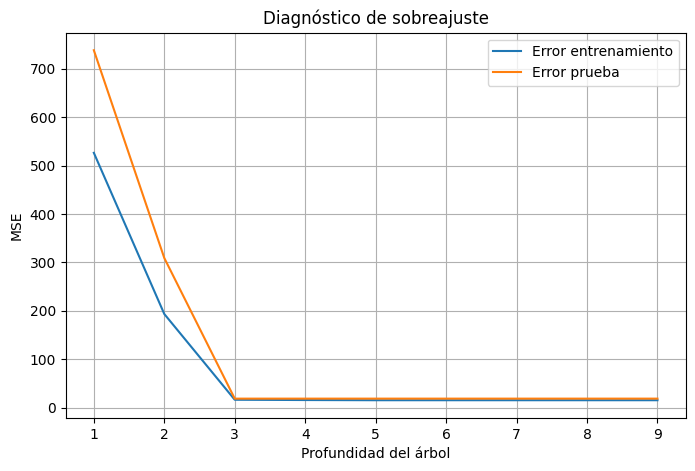

In [ ]:
df9= pd.read_csv("ANEXO 2 DF MODELO2.CSV")
x1="dm2"
x2="ganchera"
y="und"
variables_x= [x1,x2]
variable_y= y

X_train, X_test, y_train, y_test = train_test_split(
    df9[variables_x],
    df9[variable_y],
    test_size=0.00001,
    random_state=42
)



depths = range(1, 10)

train_error = []
test_error = []

for d in depths:
    
    model = DecisionTreeRegressor(
        max_depth=d,
        min_samples_split=10
    )
    
    model.fit(X_train, y_train)

    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    
    train_error.append(mean_squared_error(y_train, y_train_pred))
    test_error.append(mean_squared_error(y_test, y_test_pred))


plt.figure(figsize=(8,5))

plt.plot(depths, train_error, label="Error entrenamiento")
plt.plot(depths, test_error, label="Error prueba")

plt.xlabel("Profundidad del árbol")
plt.ylabel("MSE")
plt.title("Diagnóstico de sobreajuste")

plt.legend()
plt.grid(True)

plt.show()






In [20]:
from sklearn.metrics import mean_squared_error

MSE_train = mean_squared_error(y_train, y_train_pred)
MSE_test = mean_squared_error(y_test, y_test_pred)

overfitting_ratio = (MSE_test - MSE_train) / MSE_train

print("MSE train:", MSE_train)
print("MSE test:", MSE_test)
print("Overfitting ratio:", overfitting_ratio)

MSE train: 15.185327614854643
MSE test: 18.465160073333063
Overfitting ratio: 0.21598694092513432


In [ ]:
#importar la función de regresión 
from sklearn.linear_model import LinearRegression

#Mostrar coeficiente de correlación
r1=round(r2_score(df1[y],modelo1.predict(df1[[x1,x2]])),3)

#Entrenar el modelo
modelo1= LinearRegression()
modelo1.fit(df1[[x1,x2]],df1[y])

#Imprimir coeficientes de la ecuación optima
print(f"b0 = {modelo1.intercept_}")
print(f"b1 = {modelo1.coef_[0]}")
print(f"b1 = {modelo1.coef_[1]}")

#Predicción del modelo
y_pred = modelo1.predict([[dm2,und/ganchera]])
print("predicion:", y_pred)




#

In [ ]:
#importar modelo de árboles de decisión
from sklearn.tree import DecisionTreeRegressor

#Entenar modelo
modelo1= 
DecisionTreeRegressor(criterion= "squared_error",
                      min_samples_split=10, 
                      max_depth="None")

modelo1.fit(df1[[x1,x2]],df1[y])

In [ ]:
#importar libreria
import matplotlib.pyplot as plt

#Mostrar coeficiente de correlación
r1=round(r2_score(df1[y],modelo1.predict(df1[[x1,x2]])),3)

# Visualización árbolde decisión
plt.figure(figsize=(20,10))
plot_tree(
    modelo1,
    feature_names=x.columns,
)
plt.show()